<a href="https://colab.research.google.com/github/jiwonojo/Data-Capstone-Design---2026/blob/main/%EB%8D%B0%EC%9D%B4%ED%84%B0_%EB%88%84%EC%88%98_%ED%95%A8%EC%88%98_%EC%8B%9C%EA%B0%81%ED%99%94.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

# 데이터 불러오기
df = pd.read_csv('synthetic_fraud_dataset.csv')

In [ ]:
# 💡 [논문 인사이트 1] 재무적 압박 및 이상 소비 지표 (비율 변수)
# 1) 계좌 잔고 대비 결제 금액의 비율 (잔고를 털어가는 Bust-out 사기 패턴 포착)
df['Amount_to_Balance_Ratio'] = df['Transaction_Amount'] / df['Account_Balance']

# 2) 최근 7일 평균 결제액 대비 현재 결제액 비율 (평소 소비 패턴을 벗어난 이상치 포착)
df['Amount_to_Avg_7d_Ratio'] = df['Transaction_Amount'] / df['Avg_Transaction_Amount_7d']

# 3) 결제 후 잔액 (결제 후 잔액이 0에 수렴하는지 확인)
df['Balance_After_Transaction'] = df['Account_Balance'] - df['Transaction_Amount']


# 💡 [논문 인사이트 2] 시간대 파생 변수 (Temporal Features)
# 문자열(String) 형태의 시간 데이터를 시간형(Datetime)으로 변환
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# 4) 결제 '시간(Hour)'만 추출 (0~23)
df['Hour_of_Day'] = df['Timestamp'].dt.hour

# 5) 심야 시간대(새벽 0시~6시) 결제 여부 (정상 사용자가 잘 활동하지 않는 시간대)
# 심야 시간이면 1, 아니면 0을 부여하는 이진(Boolean) 변수 생성
df['Is_Night_Time'] = df['Hour_of_Day'].apply(lambda x: 1 if 0 <= x <= 6 else 0)

In [ ]:
# 머신러닝에 불필요한 고유 식별자(ID) 및 원본 Timestamp 컬럼 제거
df_model = df.drop(columns=['Transaction_ID', 'User_ID', 'Timestamp'])

# 원-핫 인코딩(One-Hot Encoding) 진행
# 범주형 컬럼들을 0과 1로 펼쳐줌
cat_cols = ['Transaction_Type', 'Device_Type', 'Location',
            'Merchant_Category', 'Card_Type', 'Authentication_Method']

df_final = pd.get_dummies(df_model, columns=cat_cols, drop_first=True)

# 모델링 담당자(소현님)에게 넘겨줄 최종 데이터셋 확인
print(df_final.head())

   Transaction_Amount  Account_Balance  IP_Address_Flag  \
0               39.79         93213.17                0   
1                1.19         75725.25                0   
2               28.96          1588.96                0   
3              254.32         76807.20                0   
4               31.28         92354.66                0   

   Previous_Fraudulent_Activity  Daily_Transaction_Count  \
0                             0                        7   
1                             0                       13   
2                             0                       14   
3                             0                        8   
4                             1                       14   

   Avg_Transaction_Amount_7d  Failed_Transaction_Count_7d  Card_Age  \
0                     437.63                            3        65   
1                     478.76                            4       186   
2                      50.01                            4       226   


/tmp/ipykernel_11068/1207104510.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Fraud_Label', y='Amount_to_Balance_Ratio',
/tmp/ipykernel_11068/1207104510.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Is_Night_Time', y='Fraud_Label',


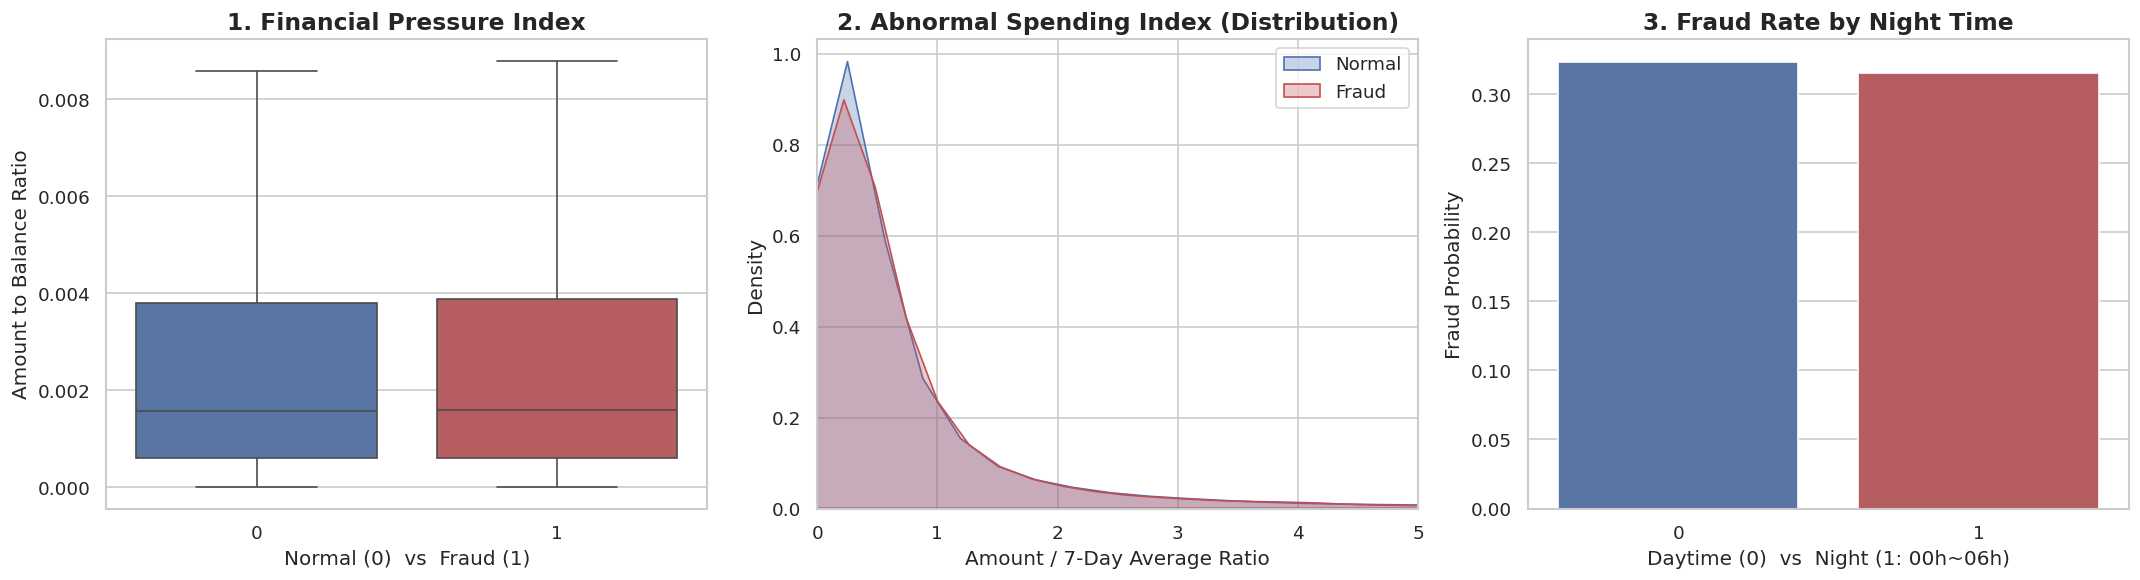

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 그래프 스타일 및 해상도 깔끔하게 설정 (PPT 삽입용)
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 120  # 고해상도 출력

# 1행 3열의 도화지(Figure) 준비
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 색상 지정: 정상(파란색 계열), 사기(빨간색 계열)
colors = ['#4C72B0', '#C44E52']

# -----------------------------------------------------------
# 1. 재무 압박 지수 (Amount_to_Balance_Ratio) - Boxplot
# -----------------------------------------------------------
# 비율 변수는 극단적인 이상치(잔고가 0에 가까운 경우 등)가 있을 수 있어
# 트렌드를 명확히 보기 위해 showfliers=False(이상치 숨김) 옵션을 적용합니다.
sns.boxplot(data=df, x='Fraud_Label', y='Amount_to_Balance_Ratio',
            ax=axes[0], palette=colors, showfliers=False)
axes[0].set_title('1. Financial Pressure Index', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Normal (0)  vs  Fraud (1)')
axes[0].set_ylabel('Amount to Balance Ratio')

# -----------------------------------------------------------
# 2. 이상 소비 지수 (Amount_to_Avg_7d_Ratio) - KDE Plot
# -----------------------------------------------------------
# 과거 평균 소비액 대비 현재 소비액의 '분포'가 사기 여부에 따라 어떻게 다른지 보여줍니다.
sns.kdeplot(data=df[df['Fraud_Label']==0], x='Amount_to_Avg_7d_Ratio',
            ax=axes[1], label='Normal', color=colors[0], fill=True, alpha=0.3)
sns.kdeplot(data=df[df['Fraud_Label']==1], x='Amount_to_Avg_7d_Ratio',
            ax=axes[1], label='Fraud', color=colors[1], fill=True, alpha=0.3)
axes[1].set_title('2. Abnormal Spending Index (Distribution)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Amount / 7-Day Average Ratio')
axes[1].set_ylabel('Density')
axes[1].set_xlim(0, 5) # 시각화를 위해 x축 범위를 0~5배율로 제한
axes[1].legend()

# -----------------------------------------------------------
# 3. 시간대 위험도 (Is_Night_Time) - Bar Plot
# -----------------------------------------------------------
# 주간(0)과 심야(1)의 '사기 발생 확률(Fraud Rate)'을 비교합니다.
sns.barplot(data=df, x='Is_Night_Time', y='Fraud_Label',
            ax=axes[2], palette=colors, errorbar=None)
axes[2].set_title('3. Fraud Rate by Night Time', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Daytime (0)  vs  Night (1: 00h~06h)')
axes[2].set_ylabel('Fraud Probability')

# 그래프 간격 조절 후 출력
plt.tight_layout()
plt.show()